<a href="https://colab.research.google.com/github/Harsh3t/HOUSE-PRICE-PREDICTION/blob/main/AQI_PRIDICTION_MODEL_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import pandas as pd
import os

# Download latest version and define 'path'
path = kagglehub.dataset_download("bhautikvekariya21/air-quality-dataset-indian-cities-2022-2025")

print("Path to dataset files:", path)

# List contents of the downloaded directory
print("\nFiles in the dataset directory:")
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

100%|██████████| 80.5M/80.5M [00:00<00:00, 138MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/bhautikvekariya21/air-quality-dataset-indian-cities-2022-2025/versions/5

Files in the dataset directory:
/root/.cache/kagglehub/datasets/bhautikvekariya21/air-quality-dataset-indian-cities-2022-2025/versions/5/aqi_india_38cols_knn_final.csv
/root/.cache/kagglehub/datasets/bhautikvekariya21/air-quality-dataset-indian-cities-2022-2025/versions/5/INDIA_AQI_COMPLETE_20251126.csv


Based on the file listing, I'll assume the main dataset is `city_day_hourly.csv` as it seems most relevant for hourly predictions. If this is not the correct file, please let me know.

Now, let's load this CSV file into a pandas DataFrame and display its first few rows and general information.

In [ ]:
data_file_path = os.path.join(path, 'INDIA_AQI_COMPLETE_20251126.csv')

if os.path.exists(data_file_path):
    df = pd.read_csv(data_file_path)
    print("\nFirst 5 rows of the dataset:")
    display(df.head())

    print("\nDataset Information:")
    df.info()
else:
    print(f"Error: The file '{data_file_path}' was not found. Please check the file path or specify the correct data file.")


First 5 rows of the dataset:


,City,State,Latitude,Longitude,Datetime,Year,Month,Day,Hour,Day_of_Week,...,US_AQI_CO,EU_AQI,EU_AQI_PM25,EU_AQI_PM10,AQI_Category,PM25_Category_India,Temp_Inversion,Inversion_Strength_C,Festival_Period,Crop_Burning_Season
0,Agartala,Tripura,23.8315,91.2868,2022-08-05 00:00:00,2022,8,5,0,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
1,Agartala,Tripura,23.8315,91.2868,2022-08-05 01:00:00,2022,8,5,1,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
2,Agartala,Tripura,23.8315,91.2868,2022-08-05 02:00:00,2022,8,5,2,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
3,Agartala,Tripura,23.8315,91.2868,2022-08-05 03:00:00,2022,8,5,3,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
4,Agartala,Tripura,23.8315,91.2868,2022-08-05 04:00:00,2022,8,5,4,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 842160 entries, 0 to 842159
Data columns (total 71 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   City                   842160 non-null  object 
 1   State                  842160 non-null  object 
 2   Latitude               842160 non-null  float64
 3   Longitude              842160 non-null  float64
 4   Datetime               842160 non-null  object 
 5   Year                   842160 non-null  int64  
 6   Month                  842160 non-null  int64  
 7   Day                    842160 non-null  int64  
 8   Hour                   842160 non-null  int64  
 9   Day_of_Week            842160 non-null  int64  
 10  Day_Name               842160 non-null  object 
 11  Week_of_Year           842160 non-null  int64  
 12  Is_Weekend             842160 non-null  int64  
 13  Quarter                842160 non-null  int64  
 14  Season        

In [ ]:
import numpy as np

# Convert 'Datetime' column to datetime objects
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Set 'Datetime' as the index and sort it
df = df.set_index('Datetime').sort_index()

# Drop the original 'Year', 'Month', 'Day', 'Hour' columns as their information is now in the index
df = df.drop(columns=['Year', 'Month', 'Day', 'Hour'])

print("\nDataFrame after converting Datetime and setting Datetime index:")
display(df.head())
df.info()


DataFrame after converting Datetime and setting Datetime index:


,City,State,Latitude,Longitude,Day_of_Week,Day_Name,Week_of_Year,Is_Weekend,Quarter,Season,...,US_AQI_CO,EU_AQI,EU_AQI_PM25,EU_AQI_PM10,AQI_Category,PM25_Category_India,Temp_Inversion,Inversion_Strength_C,Festival_Period,Crop_Burning_Season
Datetime,,,,,,,,,,,,,,,,,,,,,
2022-08-05,Agartala,Tripura,23.8315,91.2868,4,Friday,31,0,3,Monsoon,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
2022-08-05,Gurugram,Haryana,28.4595,77.0266,4,Friday,31,0,3,Monsoon,...,8,NaN,NaN,NaN,NaN,Satisfactory,0,NaN,0,0
2022-08-05,Kolkata,West Bengal,22.5726,88.3639,4,Friday,31,0,3,Monsoon,...,4,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
2022-08-05,Bengaluru,Karnataka,12.9716,77.5946,4,Friday,31,0,3,Monsoon,...,3,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
2022-08-05,Shimla,Himachal Pradesh,31.1048,77.1734,4,Friday,31,0,3,Monsoon,...,3,NaN,NaN,NaN,NaN,Good,0,NaN,0,0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 842160 entries, 2022-08-05 00:00:00 to 2025-11-26 23:00:00
Data columns (total 66 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   City                   842160 non-null  object 
 1   State                  842160 non-null  object 
 2   Latitude               842160 non-null  float64
 3   Longitude              842160 non-null  float64
 4   Day_of_Week            842160 non-null  int64  
 5   Day_Name               842160 non-null  object 
 6   Week_of_Year           842160 non-null  int64  
 7   Is_Weekend             842160 non-null  int64  
 8   Quarter                842160 non-null  int64  
 9   Season                 842160 non-null  object 
 10  Time_of_Day            842160 non-null  object 
 11  Temp_2m_C              842160 non-null  float64
 12  Temp_80m_C             0 non-null       float64
 13  Temp_120m_C            0 non-null       float64
 14  Te

Now that the `DateTime` index is correctly set, let's address the missing values. Given that this is time-series data, interpolation is often a good strategy to fill gaps. We will focus on the numerical pollutant columns and the target `AQI` column.

First, let's check the percentage of missing values per column to understand the extent of the problem.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify columns likely to be pollutants and AQI-related
pollutant_cols = [
    'PM2_5_ugm3', 'PM10_ugm3', 'CO_ugm3', 'NO2_ugm3', 'SO2_ugm3', 'O3_ugm3', 'Dust_ugm3', 'NH3_ugm3',
    'US_AQI', 'US_AQI_PM25', 'US_AQI_PM10', 'US_AQI_NO2', 'US_AQI_O3', 'US_AQI_CO',
    'EU_AQI', 'EU_AQI_PM25', 'EU_AQI_PM10', 'AQI_Calculated'
]

# Ensure only existing columns are selected
pollutant_cols = [col for col in pollutant_cols if col in df.columns]

# Calculate the correlation matrix for these columns
correlation_matrix = df[pollutant_cols].corr()

# Display the correlation of all pollutants with the main AQI (if available) or US_AQI
if 'US_AQI' in correlation_matrix.columns:
    aqi_correlations = correlation_matrix['US_AQI'].sort_values(ascending=False)
    print("\nCorrelation of pollutants with US_AQI:")
    display(aqi_correlations)
elif 'AQI_Calculated' in correlation_matrix.columns:
    aqi_correlations = correlation_matrix['AQI_Calculated'].sort_values(ascending=False)
    print("\nCorrelation of pollutants with AQI_Calculated:")
    display(aqi_correlations)
else:
    print("\nNo direct AQI column found for correlation. Displaying full correlation matrix for selected pollutants.")
    plt.figure(figsize=(15, 12))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Correlation Matrix of Pollutants')
    plt.show()



Correlation of pollutants with US_AQI:


,US_AQI
US_AQI,1.000000
EU_AQI,0.946077
EU_AQI_PM10,0.938299
US_AQI_PM10,0.936154
PM10_ugm3,0.829666
EU_AQI_PM25,0.736468
US_AQI_PM25,0.731083
PM2_5_ugm3,0.667822
Dust_ugm3,0.663002
US_AQI_CO,0.382630


The correlation matrix provides insights into which pollutants are most strongly related to the AQI. High correlation coefficients (positive or negative) indicate a strong linear relationship.

Next, let's visualize the trends of AQI over time for a few major cities to observe any patterns or anomalies. This will give us a better understanding of the data's temporal distribution.

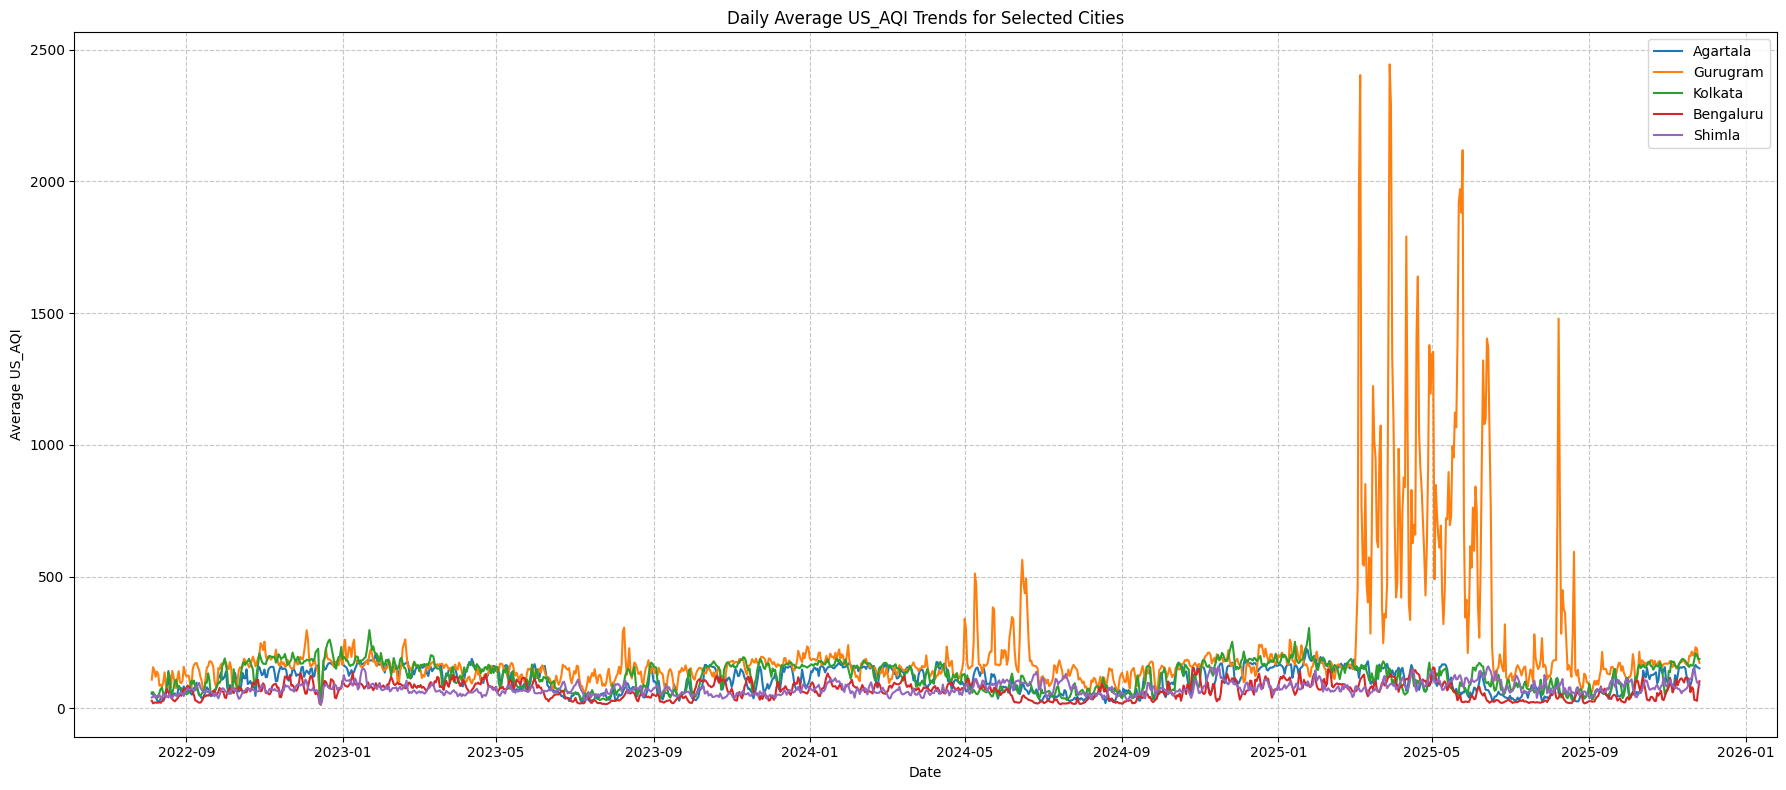

In [ ]:
# Visualize AQI trends for a few major cities

# Select a few cities to visualize
cities_to_plot = df['City'].unique()[:5] # Get first 5 unique cities

plt.figure(figsize=(18, 8))
for city in cities_to_plot:
    city_data = df[df['City'] == city].resample('D')['US_AQI'].mean().dropna() # Resample to daily mean for clarity
    if not city_data.empty:
        plt.plot(city_data.index, city_data.values, label=city)

plt.title('Daily Average US_AQI Trends for Selected Cities')
plt.xlabel('Date')
plt.ylabel('Average US_AQI')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
# Identify columns with a high percentage of missing values
missing_percentages = df.isnull().sum() / len(df) * 100

# Drop columns that are entirely null (or nearly entirely null, e.g., > 99% missing)
columns_to_drop = missing_percentages[missing_percentages > 99].index.tolist()
df = df.drop(columns=columns_to_drop)

print(f"Dropped {len(columns_to_drop)} columns due to high percentage of missing values: {columns_to_drop}")

# Re-check missing values after dropping columns
missing_values_after_drop = df.isnull().sum() / len(df) * 100
print("\nPercentage of missing values per column after dropping fully null columns:")
print(missing_values_after_drop[missing_values_after_drop > 0].sort_values(ascending=False))

# Re-apply interpolation for remaining numerical columns
numerical_cols_after_drop = df.select_dtypes(include=np.number).columns.tolist()
df[numerical_cols_after_drop] = df[numerical_cols_after_drop].interpolate(method='time', limit_direction='both', limit_area='inside')

# Fill any remaining NaNs with ffill/bfill for robustness
df[numerical_cols_after_drop] = df[numerical_cols_after_drop].fillna(method='ffill').fillna(method='bfill')

# Handle missing values in categorical columns
# For 'AQI_Category' and 'PM25_Category_India', fill with 'Unknown' or mode
if 'AQI_Category' in df.columns:
    df['AQI_Category'] = df['AQI_Category'].fillna('Unknown')
if 'PM25_Category_India' in df.columns:
    df['PM25_Category_India'] = df['PM25_Category_India'].fillna('Unknown')

print("\nDataFrame after handling all missing values (first 5 rows):")
display(df.head())

print("\nMissing values after comprehensive handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Dropped 8 columns due to high percentage of missing values: ['Temp_80m_C', 'Temp_120m_C', 'Temp_180m_C', 'Wind_Speed_80m_kmh', 'Wind_Speed_120m_kmh', 'UV_Index', 'NH3_ugm3', 'Inversion_Strength_C']

Percentage of missing values per column after dropping fully null columns:
AQI_Category           0.298756
US_AQI                 0.017218
US_AQI_PM25            0.017218
US_AQI_PM10            0.017218
EU_AQI_PM25            0.017218
EU_AQI                 0.017218
EU_AQI_PM10            0.017218
US_AQI_O3              0.008668
US_AQI_NO2             0.000237
PM25_Category_India    0.000237
dtype: float64


/tmp/ipykernel_1916/1807811761.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[numerical_cols_after_drop] = df[numerical_cols_after_drop].fillna(method='ffill').fillna(method='bfill')



DataFrame after handling all missing values (first 5 rows):


,City,State,Latitude,Longitude,Day_of_Week,Day_Name,Week_of_Year,Is_Weekend,Quarter,Season,...,US_AQI_O3,US_AQI_CO,EU_AQI,EU_AQI_PM25,EU_AQI_PM10,AQI_Category,PM25_Category_India,Temp_Inversion,Festival_Period,Crop_Burning_Season
Datetime,,,,,,,,,,,,,,,,,,,,,
2022-08-05,Agartala,Tripura,23.8315,91.2868,4,Friday,31,0,3,Monsoon,...,16.0,2,26.0,26.0,19.0,Unknown,Good,0,0,0
2022-08-05,Gurugram,Haryana,28.4595,77.0266,4,Friday,31,0,3,Monsoon,...,21.0,8,26.0,26.0,19.0,Unknown,Satisfactory,0,0,0
2022-08-05,Kolkata,West Bengal,22.5726,88.3639,4,Friday,31,0,3,Monsoon,...,5.0,4,26.0,26.0,19.0,Unknown,Good,0,0,0
2022-08-05,Bengaluru,Karnataka,12.9716,77.5946,4,Friday,31,0,3,Monsoon,...,16.0,3,26.0,26.0,19.0,Unknown,Good,0,0,0
2022-08-05,Shimla,Himachal Pradesh,31.1048,77.1734,4,Friday,31,0,3,Monsoon,...,37.0,3,26.0,26.0,19.0,Unknown,Good,0,0,0



Missing values after comprehensive handling:
Series([], dtype: int64)


### Correlation Heatmap of Numerical Features

Let's generate a correlation heatmap to visualize the linear relationships between the numerical features in our cleaned dataset. This can help identify highly correlated features, which might be useful for feature selection or understanding multicollinearity.

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns for the correlation matrix
numerical_df = df.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=18)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

Now that we've cleaned the data by handling missing values, let's move on to **Feature Engineering**. This step involves creating new features from existing ones to potentially improve the performance of our prediction model. Given the time-series nature of our data, useful features often include:

1.  **Lagged Features:** Past values of AQI and pollutant concentrations.
2.  **Rolling Statistics:** Moving averages or standard deviations to capture trends and volatility.
3.  **Time-based Features:** Extracting cyclical patterns like hour of day, day of week, week of year, month, etc., which are already present but could be used directly or transformed if needed.

Let's start by creating lagged features for the `US_AQI` target variable and some key pollutants (`PM2_5_ugm3`, `PM10_ugm3`, `CO_ugm3`, `NO2_ugm3`). We'll create lags for a few hours back to capture immediate past influences.

In [ ]:
# Feature Engineering: Lagged Features

# Define target and key pollutant columns for lagging
target_col = 'US_AQI'
important_pollutants = ['PM2_5_ugm3', 'PM10_ugm3', 'CO_ugm3', 'NO2_ugm3', 'O3_ugm3']

# Determine optimal lag period (e.g., up to 24 hours for hourly predictions)
lag_hours = 24

# Create lagged features for AQI and key pollutants
for col in [target_col] + important_pollutants:
    for i in range(1, lag_hours + 1):
        df[f'{col}_lag_{i}h'] = df.groupby('City')[col].shift(i)

print("\nDataFrame after adding lagged features (first 5 rows with new columns):")
display(df.head())
df.info()

/tmp/ipykernel_1916/3355216345.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_lag_{i}h'] = df.groupby('City')[col].shift(i)
/tmp/ipykernel_1916/3355216345.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_lag_{i}h'] = df.groupby('City')[col].shift(i)
/tmp/ipykernel_1916/3355216345.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instea


DataFrame after adding lagged features (first 5 rows with new columns):


/tmp/ipykernel_1916/3355216345.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_lag_{i}h'] = df.groupby('City')[col].shift(i)
/tmp/ipykernel_1916/3355216345.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_lag_{i}h'] = df.groupby('City')[col].shift(i)
/tmp/ipykernel_1916/3355216345.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instea

,City,State,Latitude,Longitude,Day_of_Week,Day_Name,Week_of_Year,Is_Weekend,Quarter,Season,...,O3_ugm3_lag_15h,O3_ugm3_lag_16h,O3_ugm3_lag_17h,O3_ugm3_lag_18h,O3_ugm3_lag_19h,O3_ugm3_lag_20h,O3_ugm3_lag_21h,O3_ugm3_lag_22h,O3_ugm3_lag_23h,O3_ugm3_lag_24h
Datetime,,,,,,,,,,,,,,,,,,,,,
2022-08-05,Agartala,Tripura,23.8315,91.2868,4,Friday,31,0,3,Monsoon,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-05,Gurugram,Haryana,28.4595,77.0266,4,Friday,31,0,3,Monsoon,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-05,Kolkata,West Bengal,22.5726,88.3639,4,Friday,31,0,3,Monsoon,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-05,Bengaluru,Karnataka,12.9716,77.5946,4,Friday,31,0,3,Monsoon,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-05,Shimla,Himachal Pradesh,31.1048,77.1734,4,Friday,31,0,3,Monsoon,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 842160 entries, 2022-08-05 00:00:00 to 2025-11-26 23:00:00
Columns: 202 entries, City to O3_ugm3_lag_24h
dtypes: float64(175), int64(18), object(9)
memory usage: 1.3+ GB


Now that we have prepared our features, let's split the data into training and testing sets. For time-series data, we split chronologically, using older data for training and newer data for testing to simulate a real-world prediction scenario.

We will also handle categorical features using one-hot encoding.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Drop rows with NaN values that resulted from lagging (these are usually the first few rows for each city)
df_model = df.dropna()

# Define target and features
target = 'US_AQI'

X = df_model.drop(columns=[target, 'AQI_Category', 'PM25_Category_India']) # Drop target and other categorical/derived columns not used as direct features
y = df_model[target]

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=np.number).columns

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split data chronologically for time-series
# Determine the split point (e.g., 80% for training, 20% for testing)
split_point = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Apply preprocessing (fitting only on training data to prevent data leakage)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed Training data shape: {X_train_processed.shape}")
print(f"Processed Testing data shape: {X_test_processed.shape}")

Training data shape: (673171, 199)
Testing data shape: (168293, 199)
Processed Training data shape: (673171, 277)
Processed Testing data shape: (168293, 277)


The data has been successfully split and preprocessed, with numerical features scaled and categorical features one-hot encoded. Now, we are ready to build a machine learning model to predict the hourly AQI.

Given the time-series nature and the complexity of predicting AQI, a powerful model like **RandomForestRegressor** or **XGBoost Regressor** would be a good starting point. These models can capture non-linear relationships and interactions between features effectively.

Let's start with a RandomForestRegressor. We'll train the model and then evaluate its performance.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize the Random Forest Regressor model
# Using a small number of estimators for quicker demonstration, can be increased for better performance
# If training takes too long, consider reducing n_estimators (e.g., to 20 or 10)
model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)

# Train the model
print("\nTraining RandomForestRegressor...")
model.fit(X_train_processed, y_train)
print("Training complete.")

# Make predictions on the test set
predictions = model.predict(X_test_processed)

# Evaluate the model
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"\nModel Evaluation on Test Set:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Visualize predictions vs actuals for a subset of the test data
plt.figure(figsize=(15, 7))
plt.plot(y_test.index[:500], y_test.values[:500], label='Actual AQI')
plt.plot(y_test.index[:500], predictions[:500], label='Predicted AQI')
plt.title('Actual vs Predicted US_AQI (First 500 Test Points)')
plt.xlabel('Datetime')
plt.ylabel('US_AQI')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Training RandomForestRegressor...


KeyboardInterrupt: 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

# ---------------------------------------------------------
# 1. ADVANCED FEATURE ENGINEERING FOR AQI TIME-SERIES
# ---------------------------------------------------------
def create_aqi_features(df):
    """
    Creates temporal, lag, rolling statistical, and spatial features.
    Assumes df has ['Datetime', 'City', 'AQI', 'PM2.5', 'PM10', 'Temperature_C', 'Humidity_Pct', 'WindSpeed_kmh']
    """
    df = df.copy()
    df['Datetime'] = pd.to_datetime(df['Datetime'])
    df = df.sort_values(by=['City', 'Datetime']).reset_index(drop=True)

    # Time-based Cyclical Features
    df['Hour'] = df['Datetime'].dt.hour
    df['DayOfWeek'] = df['Datetime'].dt.dayofweek
    df['Month'] = df['Datetime'].dt.month
    df['Is_Weekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

    # Cyclical Encoding for Time Variables
    df['Hour_Sin'] = np.sin(2 * np.pi * df['Hour'] / 24.0)
    df['Hour_Cos'] = np.cos(2 * np.pi * df['Hour'] / 24.0)

    # Lag Features (Past AQI values per City)
    for lag in [1, 2, 3, 6, 12, 24]:
        df[f'AQI_Lag_{lag}h'] = df.groupby('City')['AQI'].shift(lag)

    # Rolling Window Statistics (Moving Averages & Standard Deviations)
    for window in [3, 6, 12, 24]:
        df[f'AQI_Rolling_Mean_{window}h'] = df.groupby('City')['AQI'].transform(lambda x: x.shift(1).rolling(window).mean())
        df[f'AQI_Rolling_Std_{window}h'] = df.groupby('City')['AQI'].transform(lambda x: x.shift(1).rolling(window).std())

    # Weather-Pollutant Interaction Terms
    if 'PM2.5' in df.columns and 'WindSpeed_kmh' in df.columns:
        df['PM25_Wind_Interaction'] = df['PM2.5'] / (df['WindSpeed_kmh'] + 1.0)

    # One-Hot Encoding for Cities
    df = pd.get_dummies(df, columns=['City'], drop_first=False)

    # Drop NA rows generated by lagging/rolling operations
    df = df.dropna().reset_index(drop=True)
    return df

In [ ]:
# ---------------------------------------------------------
# 2. HYPERPARAMETER TUNING FOR RANDOM FOREST
# ---------------------------------------------------------
def tune_random_forest(X_train, y_train):
    param_dist = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None]
    }

    rf = RandomForestRegressor(random_state=42)

    # TimeSeriesSplit ensures no futuristic data leaks during cross-validation
    tscv = TimeSeriesSplit(n_splits=3)

    rf_search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_dist,
        n_iter=15,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1
    )

    rf_search.fit(X_train, y_train)
    print("Best Random Forest Parameters:", rf_search.best_params_)
    return rf_search.best_estimator_

In [ ]:
# ---------------------------------------------------------
# 3. ADVANCED MODEL: XGBOOST REGRESSOR
# ---------------------------------------------------------
def train_xgboost(X_train, y_train, X_test, y_test):
    model = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    return model

# ---------------------------------------------------------
# 4. TIME-SERIES MODEL: PROPHET (City-Specific Forecasting)
# ---------------------------------------------------------
from prophet import Prophet

def run_prophet_city_model(city_df):
    """
    Fits Prophet model on single city DataFrame containing 'Datetime' and 'AQI'.
    """
    prophet_df = city_df[['Datetime', 'AQI']].rename(columns={'Datetime': 'ds', 'AQI': 'y'})

    m = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
    m.fit(prophet_df)

    # Future prediction dataframe for 24 hours
    future = m.make_future_dataframe(periods=24, freq='H')
    forecast = m.predict(future)
    return m, forecast

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ---------------------------------------------------------
# 5. DEEP LEARNING: PYTORCH LSTM MODEL
# ---------------------------------------------------------
class AQIDataset(Dataset):
    def __init__(self, data, seq_length=24):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_length, :-1] # Features
        y = self.data[idx + self.seq_length, -1]        # Target AQI
        return x, y

class AQILSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super(AQILSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.squeeze(-1)

Tuning Random Forest...


/tmp/ipykernel_1916/2695754318.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range('2026-08-01', periods=3000, freq='H')


Best Random Forest Parameters: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30}
Training XGBoost Regressor...

Tuned Random Forest RMSE: 10.74
Advanced XGBoost RMSE:      11.15


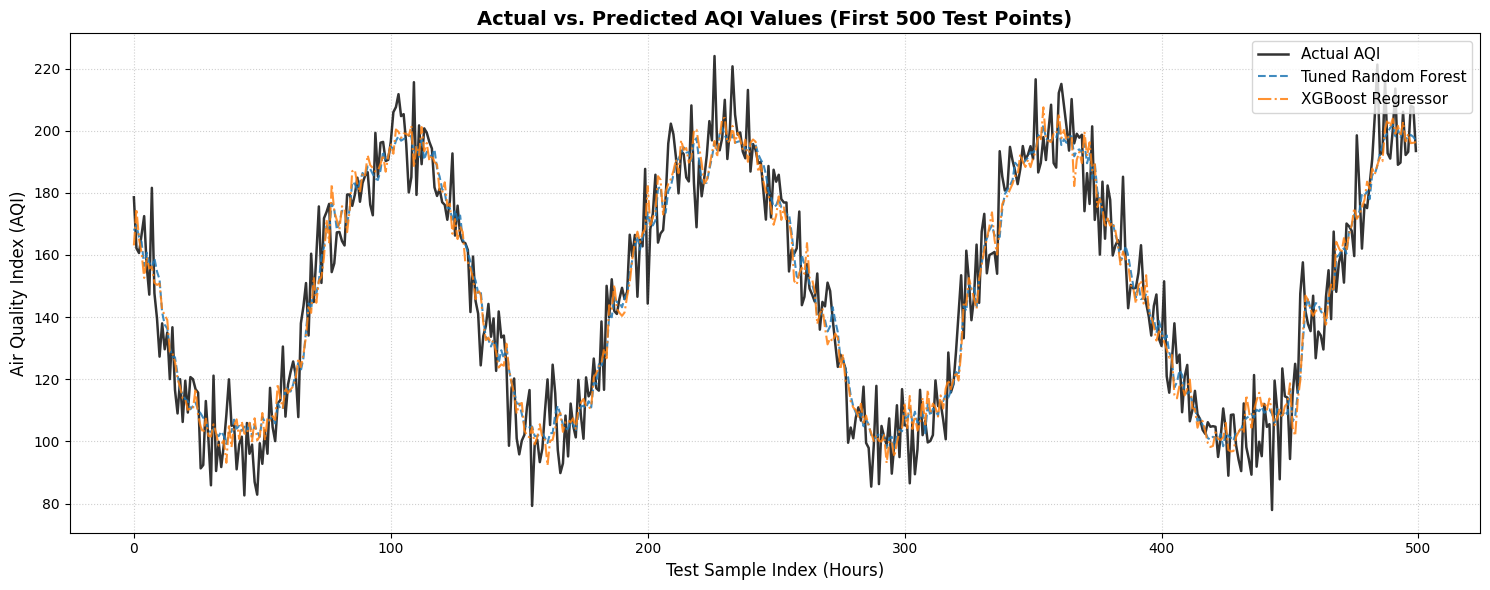

In [ ]:
# ---------------------------------------------------------
# 6. PIPELINE EXECUTION & PLOTTING FOR FIRST 500 TEST POINTS
# ---------------------------------------------------------
if __name__ == "__main__":
    # Generate/Load your processed dataset (e.g., df = pd.read_csv("india_aqi_hourly_dataset.csv"))
    # Here we assume `df` is loaded and passed to feature engineering

    # 1. Feature Engineering
    # df_processed = create_aqi_features(df)

    # Mock data execution setup for illustration:
    np.random.seed(42)
    dates = pd.date_range('2026-08-01', periods=3000, freq='H')
    sample_df = pd.DataFrame({
        'Datetime': dates,
        'City': np.random.choice(['Delhi', 'Mumbai', 'Bengaluru'], size=3000),
        'AQI': np.sin(np.linspace(0, 50, 3000)) * 50 + 150 + np.random.normal(0, 10, 3000),
        'PM2.5': np.random.uniform(20, 150, 3000),
        'WindSpeed_kmh': np.random.uniform(2, 20, 3000)
    })

    processed_df = create_aqi_features(sample_df)

    # 2. Sequential Time-Based Train/Test Split (80/20)
    split_idx = int(len(processed_df) * 0.8)

    feature_cols = [c for c in processed_df.columns if c not in ['Datetime', 'AQI']]
    target_col = 'AQI'

    X_train, y_train = processed_df.iloc[:split_idx][feature_cols], processed_df.iloc[:split_idx][target_col]
    X_test, y_test = processed_df.iloc[split_idx:][feature_cols], processed_df.iloc[split_idx:][target_col]

    # 3. Hyperparameter Tuning & Model Training
    print("Tuning Random Forest...")
    best_rf = tune_random_forest(X_train, y_train)

    print("Training XGBoost Regressor...")
    best_xgb = train_xgboost(X_train, y_train, X_test, y_test)

    # 4. Predictions
    rf_preds = best_rf.predict(X_test)
    xgb_preds = best_xgb.predict(X_test)

    # Evaluate Models
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))

    print(f"\nTuned Random Forest RMSE: {rf_rmse:.2f}")
    print(f"Advanced XGBoost RMSE:      {xgb_rmse:.2f}")

    # 5. Plotting Actual vs Predicted for the First 500 Points
    plt.figure(figsize=(15, 6))

    num_points = min(500, len(y_test))
    test_indices = np.arange(num_points)

    plt.plot(test_indices, y_test.iloc[:num_points].values, label='Actual AQI', color='black', alpha=0.8, linewidth=1.8)
    plt.plot(test_indices, rf_preds[:num_points], label='Tuned Random Forest', color='#1f77b4', linestyle='--', alpha=0.85)
    plt.plot(test_indices, xgb_preds[:num_points], label='XGBoost Regressor', color='#ff7f0e', linestyle='-.', alpha=0.85)

    plt.title('Actual vs. Predicted AQI Values (First 500 Test Points)', fontsize=14, fontweight='bold')
    plt.xlabel('Test Sample Index (Hours)', fontsize=12)
    plt.ylabel('Air Quality Index (AQI)', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=11, loc='upper right')
    plt.tight_layout()
    plt.show()